# **Logistic Regression**

## **1. Import Libraries**

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
# Scikit-learn – preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
 
# Scikit-learn – model
from sklearn.linear_model import LogisticRegression
 
# Scikit-learn – evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    accuracy_score,
    recall_score,        
    precision_score,
    matthews_corrcoef
)
 
# Imbalanced-learn – SMOTE for oversampling 
from imblearn.over_sampling import SMOTE
 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
 
print("All libraries imported successfully.")

All libraries imported successfully.


## **2. Load the Dataset**

In [2]:
df = pd.read_csv('creditcard.csv')
 
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")
df.head()

Dataset shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **3. Exploratory Data Analysis (EDA)**

In [3]:
# Basic Dataset Information
print("Dataset Information")
df.info()
print("\nStatistical Summary")
df.describe()
 

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
# Missing Values Check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


Class Distribution:
  Legitimate (0): 284,315 (99.8273%)
  Fraudulent (1): 492 (0.1727%)


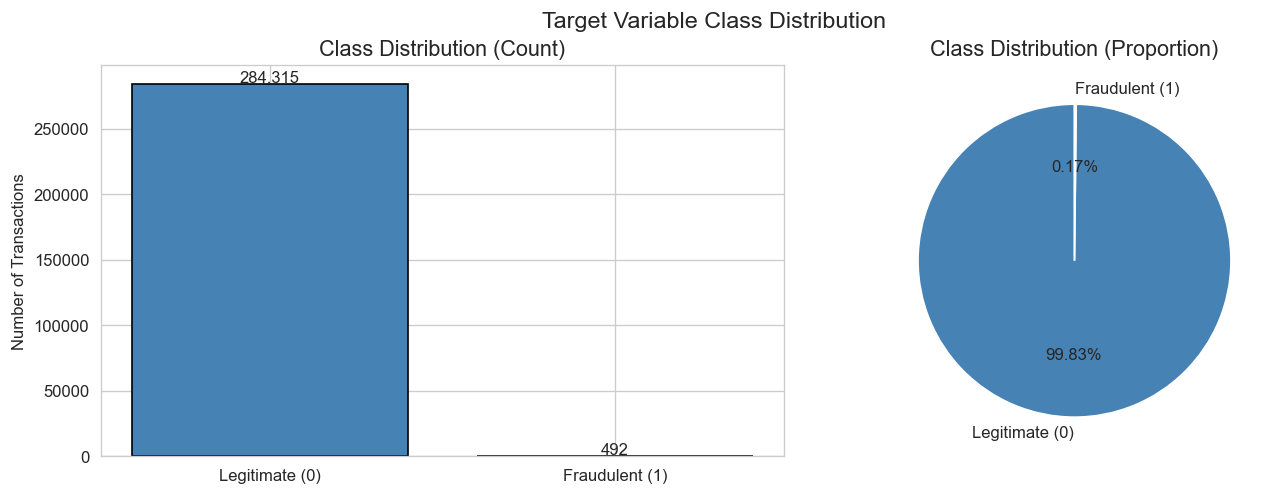

In [5]:
# Class Distribution
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100
 
print("Class Distribution:")
print(f"  Legitimate (0): {class_counts[0]:,} ({class_pct[0]:.4f}%)")
print(f"  Fraudulent (1): {class_counts[1]:,} ({class_pct[1]:.4f}%)")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha='center', fontsize=10)
 
axes[1].pie(class_counts.values, labels=['Legitimate (0)', 'Fraudulent (1)'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)
 
plt.tight_layout()
plt.suptitle('Target Variable Class Distribution', fontsize=14, y=1.02)
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

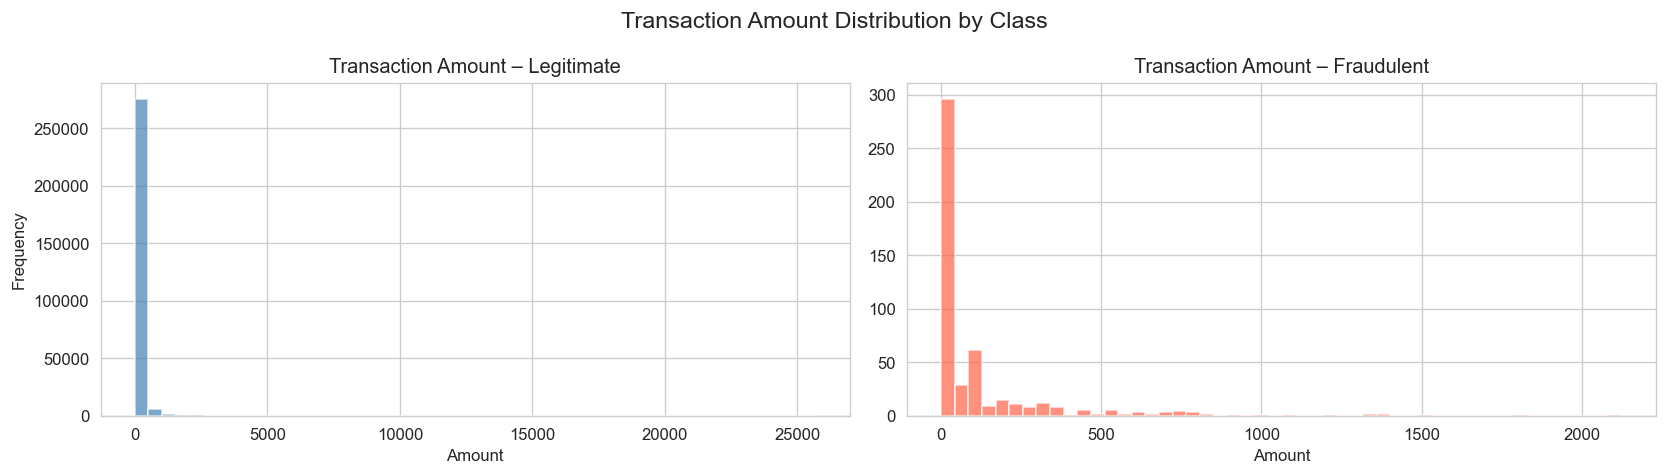

Mean fraudulent transaction amount : $122.21
Mean legitimate transaction amount : $88.29


In [6]:
# Transaction Amount Distribution by Class
fraud_amounts = df[df['Class'] == 1]['Amount']
legit_amounts = df[df['Class'] == 0]['Amount']
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
axes[0].hist(legit_amounts, bins=50, color='steelblue', alpha=0.7, label='Legitimate')
axes[0].set_title('Transaction Amount – Legitimate')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
 
axes[1].hist(fraud_amounts, bins=50, color='tomato', alpha=0.7, label='Fraudulent')
axes[1].set_title('Transaction Amount – Fraudulent')
axes[1].set_xlabel('Amount')
 
plt.suptitle('Transaction Amount Distribution by Class', fontsize=14)
plt.tight_layout()
plt.savefig('amount_distribution.png', bbox_inches='tight')
plt.show()
 
print(f"Mean fraudulent transaction amount : ${fraud_amounts.mean():.2f}")
print(f"Mean legitimate transaction amount : ${legit_amounts.mean():.2f}")

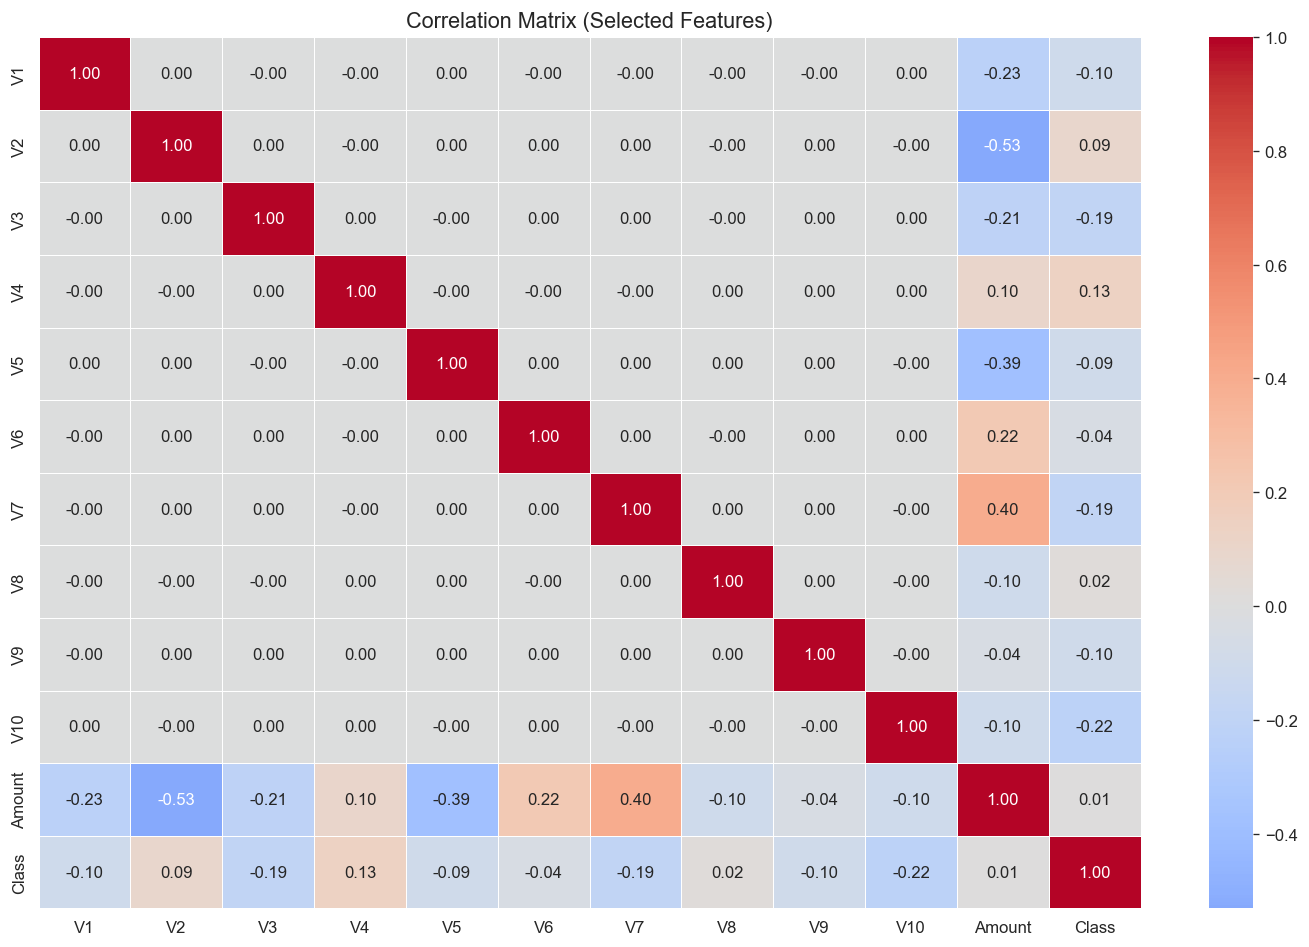

In [7]:
# Correlation Heatmap
corr_cols = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','Amount','Class']
plt.figure(figsize=(12, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0)
plt.title('Correlation Matrix (Selected Features)', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## **4. Data Preprocessing**

In [8]:
# Drop Duplicate Rows
initial_shape = df.shape
df.drop_duplicates(inplace=True)
print(f"Rows before deduplication : {initial_shape[0]:,}")
print(f"Rows after  deduplication : {df.shape[0]:,}")
print(f"Duplicates removed        : {initial_shape[0] - df.shape[0]:,}")

Rows before deduplication : 284,807
Rows after  deduplication : 283,726
Duplicates removed        : 1,081


In [9]:
# Feature Scaling 
scaler = StandardScaler()
 
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = scaler.fit_transform(df[['Time']])
 
# Drop original unscaled columns
df.drop(columns=['Amount', 'Time'], inplace=True)
 
print(f"Dataset shape after scaling: {df.shape}")

Dataset shape after scaling: (283726, 31)


In [10]:
# Separate Features and Target
X = df.drop(columns=['Class'])
y = df['Class']
 
print(f"Feature matrix X shape : {X.shape}")
print(f"Target vector y shape  : {y.shape}")
print(f"\nClass counts:\n{y.value_counts()}")
 

Feature matrix X shape : (283726, 30)
Target vector y shape  : (283726,)

Class counts:
Class
0    283253
1       473
Name: count, dtype: int64


In [11]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
 
print(f"Training set   : {X_train.shape[0]:,} samples")
print(f"Test set       : {X_test.shape[0]:,}  samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set   : 226,980 samples
Test set       : 56,746  samples

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [12]:
# Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
 
print(f"\nBefore SMOTE – Training class distribution:\n{y_train.value_counts()}")
print(f"\nAfter  SMOTE – Training class distribution:\n{pd.Series(y_train_sm).value_counts()}")
print(f"\nNew training set size: {X_train_sm.shape[0]:,} samples")


Before SMOTE – Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

After  SMOTE – Training class distribution:
Class
0    226602
1    226602
Name: count, dtype: int64

New training set size: 453,204 samples


## **5. Model Training – Logistic Regression**

In [13]:
lr_model = LogisticRegression(
    penalty='l2',            
    C=1.0,                   
    solver='lbfgs',          
    max_iter=1000,           
    class_weight='balanced', 
    random_state=42
)
 
lr_model.fit(X_train_sm, y_train_sm)
print("Model training complete.")

Model training complete.


## **6. Model Evaluation – Default Threshold (0.5)**

In [14]:
# Predictions
y_pred       = lr_model.predict(X_test)           
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

In [15]:
# Core Performance Metrics
acc       = accuracy_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc       = roc_auc_score(y_test, y_pred_proba)
pr_auc    = average_precision_score(y_test, y_pred_proba)
mcc       = matthews_corrcoef(y_test, y_pred)
 
print("=" * 55)
print("  LOGISTIC REGRESSION – RESULTS (Default Threshold 0.5)")
print("=" * 55)
print(f"  Accuracy               : {acc:.4f}")
print(f"  Recall    (Fraud)      : {recall:.4f} ")
print(f"  Precision (Fraud)      : {precision:.4f} ")
print(f"  F1-Score  (Fraud)      : {f1:.4f}")
print(f"  ROC-AUC Score          : {roc:.4f}")
print(f"  Average Precision (PR) : {pr_auc:.4f}")
print(f"  Matthews Corr Coeff    : {mcc:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))

  LOGISTIC REGRESSION – RESULTS (Default Threshold 0.5)
  Accuracy               : 0.9737
  Recall    (Fraud)      : 0.8737 
  Precision (Fraud)      : 0.0531 
  F1-Score  (Fraud)      : 0.1002
  ROC-AUC Score          : 0.9619
  Average Precision (PR) : 0.6768
  Matthews Corr Coeff    : 0.2118

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
  Fraudulent       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



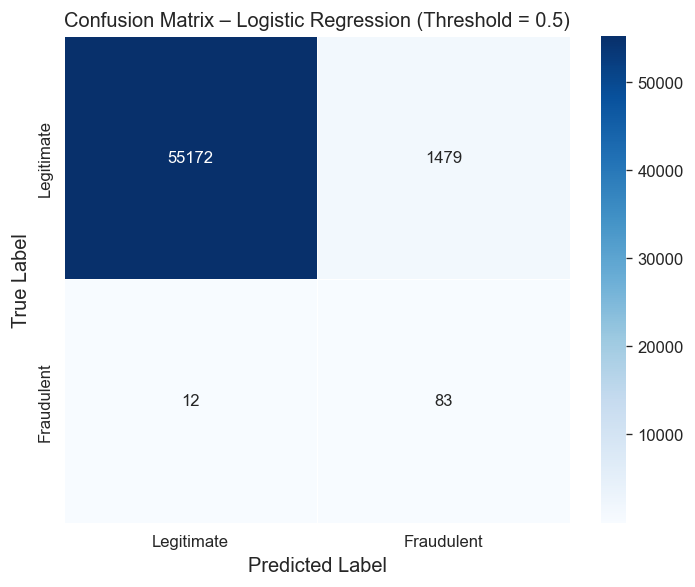

True  Negatives (TN): 55,172 
False Positives (FP): 1,479 
False Negatives (FN): 12 
True  Positives (TP): 83 


In [16]:
# Confusion Matrix (Default Threshold 0.5)
cm = confusion_matrix(y_test, y_pred)
 
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix – Logistic Regression (Threshold = 0.5)', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_lr_default.png', bbox_inches='tight')
plt.show()
 
tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (TN): {tn:,} ")
print(f"False Positives (FP): {fp:,} ")
print(f"False Negatives (FN): {fn:,} ")
print(f"True  Positives (TP): {tp:,} ")

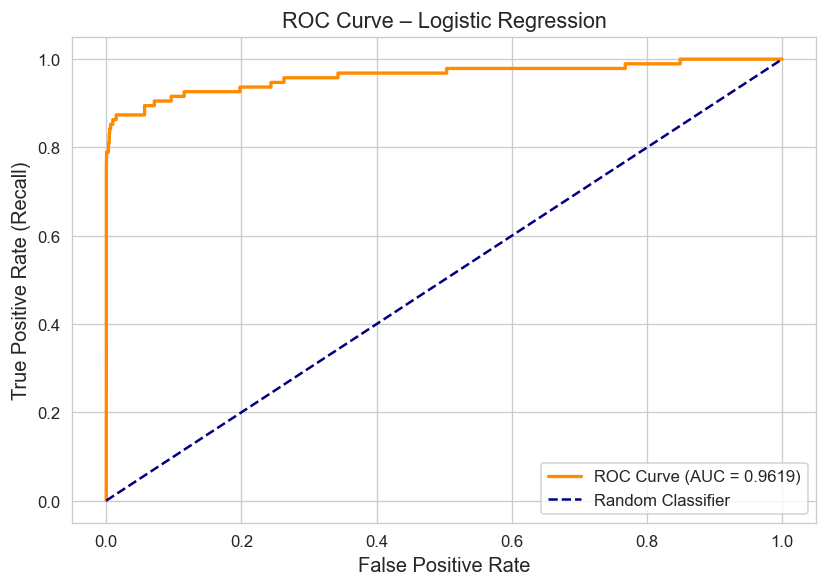

In [17]:
# ROC Curve 
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
 
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve – Logistic Regression', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_lr.png', bbox_inches='tight')
plt.show()

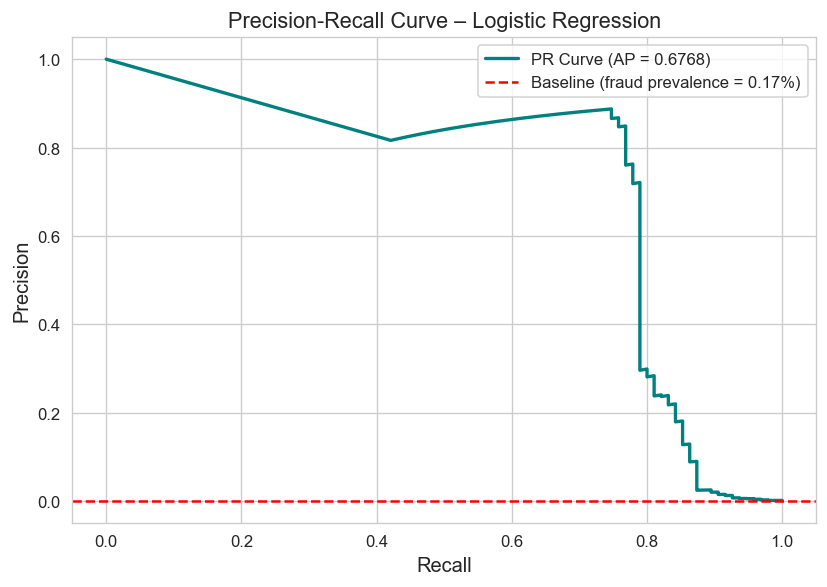

In [18]:
# Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
 
plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, color='teal', lw=2,
         label=f'PR Curve (AP = {pr_auc:.4f})')
plt.axhline(y=class_pct[1]/100, color='red', linestyle='--', lw=1.5,
            label=f'Baseline (fraud prevalence = {class_pct[1]:.2f}%)')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve – Logistic Regression', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_lr.png', bbox_inches='tight')
plt.show()